# Applied Machine Learning

## Assignment5 - ShunFai Lee

In [143]:
#import all needed libraries
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score,GridSearchCV,cross_validate
from sklearn.metrics import confusion_matrix, make_scorer, recall_score, precision_score, accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from io import StringIO
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import tree, neural_network
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline, Pipeline

In [144]:
# Define some common functions
def tpr_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp / (tp + fn)

def fpr_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn)

def all_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {'tpr':tp / (tp + fn),
            'fpr':fp / (fp + tn),
            'precision':tp / (fp + tp),
            'accu':(tp+tn)/(tp+tn+fp+fn),
            'f1':(2*tp)/(2*tp+fp+fn)}

scoring_metrics = {
    'accuracy': 'accuracy',
    "tpr": make_scorer(tpr_score),
    "fpr": make_scorer(fpr_score),
    "precision": make_scorer(precision_score, zero_division=0)
}

In [145]:
# function to drop duplicate rows
def drop_dup(df:pd.DataFrame):
    df["is_duplicate"]= df.duplicated()
    index_to_drop = df[df['is_duplicate']==True].index
    if len(index_to_drop)==0:
        df.drop(columns='is_duplicate', inplace=True)
    else:
        df.drop(index_to_drop, inplace=True)
        df.drop(columns='is_duplicate', inplace=True)

#function to drop rows with less than half of features available
def drop_tooManyNA(df:pd.DataFrame):
    df.dropna(thresh=len(df.columns)//2,inplace=True)



#### Preprocessing of dataset

In [146]:
#load data set
df_train = pd.read_csv("heart_dataset.csv")

print(df_train.dtypes)
# Sanity check
print(f'N={len(df_train)}, M={len(df_train.columns)}')
df_train['duplicate']=df_train.duplicated()
print(f'Number of duplicate: {len(df_train[df_train['duplicate']==True])}')
df_train=df_train.drop(columns=['duplicate'])
for x in df_train.columns:
    print(f'number of null values at column {x}: {len(df_train[df_train[x].isnull()==True])}')
df_train.head()



Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object
N=918, M=12
Number of duplicate: 0
number of null values at column Age: 0
number of null values at column Sex: 0
number of null values at column ChestPainType: 0
number of null values at column RestingBP: 0
number of null values at column Cholesterol: 0
number of null values at column FastingBS: 0
number of null values at column RestingECG: 0
number of null values at column MaxHR: 0
number of null values at column ExerciseAngina: 0
number of null values at column Oldpeak: 0
number of null values at column ST_Slope: 0
number of null values at column HeartDisease: 0


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


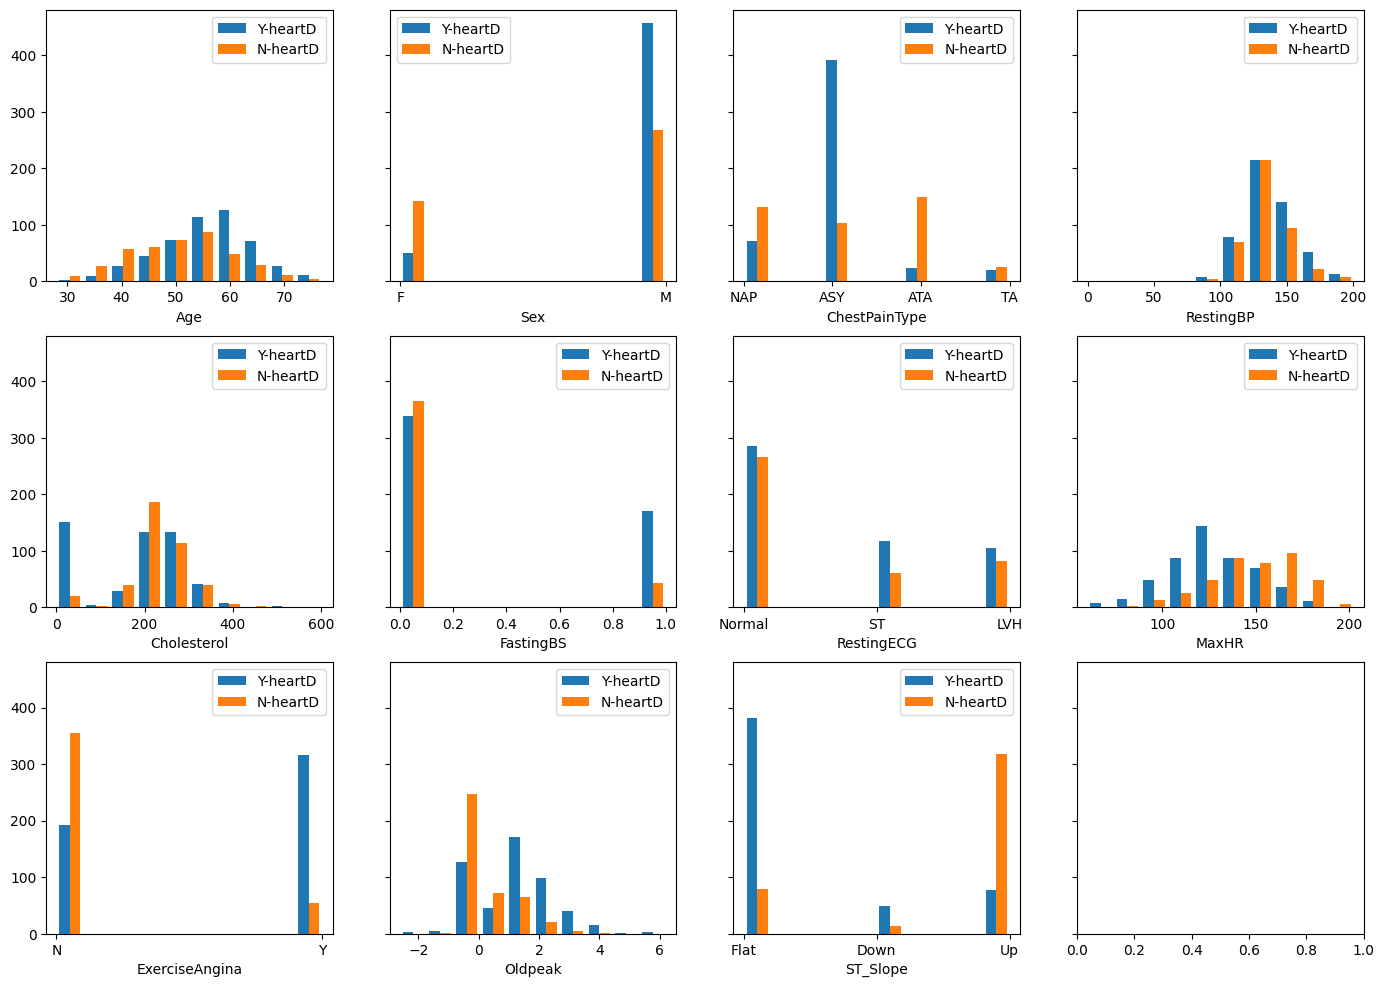

In [147]:
def plt_var(df, class_label, _ax, _col):
    _ax.hist([df[df[class_label]==1][_col],df[df[class_label]==0][_col]], label=['Y-heartD','N-heartD'])
    _ax.set_xlabel(_col)
    _ax.legend()    


def plot_feature_hist(df,col_start, col_end):
    #4 plot in a row max
    plot_per_row = 4
    #extract feature label
    columns = df_train.columns[col_start:col_end+1]
    #extract the class label
    classlabel = df_train.columns[-1]
    #calculate number of cols needed
    cols = min(len(columns),plot_per_row)
    rows = (len(columns)+1)//plot_per_row
    _, axs = plt.subplots(nrows=rows, ncols=cols, figsize=(17, plot_per_row*rows), sharey=True)
    for i in range(len(columns)):
        x = i%plot_per_row
        y = i//plot_per_row
        plt_var(df_train, classlabel ,axs[y,x], columns[i])
    plt.show()
    
#plot histogram of all features to examine outliners
plot_feature_hist(df_train,0,-2)

In [148]:
#drop entry with more than half NA values
drop_tooManyNA(df_train)
#drop duplicates
drop_dup(df_train)

#separate class and data
df_train_X = df_train.drop(columns="HeartDisease")
df_train_Y = df_train["HeartDisease"]

# Sanity check
print(f'N={len(df_train_X)}, M={len(df_train_X.columns)}')

#define the columns that need some handling by types
numeric_cols = ['Age','RestingBP','Cholesterol','MaxHR']
categorical_cols = ['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']

#set up the pipelines for different columns, with differnt impute methods and standardization/one hot encode
numeric_transform = Pipeline([('imputer',SimpleImputer(strategy='mean')),('scaler',StandardScaler())])
cat_transform = Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('encoder',OneHotEncoder(categories='auto', drop='first'))])
other_transform = Pipeline([('imputer',SimpleImputer(strategy='most_frequent'))])

#set up the transformer
preprocessor = ColumnTransformer(transformers=[('numeric',numeric_transform,numeric_cols),('categorical',cat_transform,categorical_cols)],remainder=other_transform,verbose_feature_names_out=False)


N=918, M=11


In [149]:
# 10-fold CV evaluation of a classifier on a pipeline
def eval_classifier_pipeline(pipeline, _X, _y):
    accuracies = []
    kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
    for train_index, test_index in kf.split(_X, _y):
        pipeline.fit(_X.iloc[train_index], _y.iloc[train_index])
        y_pred = pipeline.predict(_X.iloc[test_index])
        accuracies += [accuracy_score(_y.iloc[test_index], y_pred)]
    return np.array(accuracies)

#calculate the CV performance on the whole data set with transform pipeline
_clf = [GaussianNB(),SVC(kernel='linear',probability=True),neural_network.MLPClassifier(),tree.DecisionTreeClassifier(),RandomForestClassifier()]
CV_result = {}
for c in _clf:
    pipe_lr = make_pipeline(preprocessor,c)
    result = eval_classifier_pipeline(pipe_lr,df_train_X,df_train_Y)
    CV_result.update({c.__class__.__name__:[result.mean(),result.std()]})
for r in CV_result:
    print(f'{r}:10-fold CV accuracy:{CV_result[r][0]:.2f}{chr(177)}{CV_result[r][1]:.2f}')


g:\phoenixDocuments\GitHub\MachineLearning\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
g:\phoenixDocuments\GitHub\MachineLearning\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
g:\phoenixDocuments\GitHub\MachineLearning\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
g:\phoenixDocuments\GitHub\MachineLearning\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converge

GaussianNB:10-fold CV accuracy:0.86±0.04
SVC:10-fold CV accuracy:0.86±0.03
MLPClassifier:10-fold CV accuracy:0.87±0.03
DecisionTreeClassifier:10-fold CV accuracy:0.79±0.04
RandomForestClassifier:10-fold CV accuracy:0.87±0.04


### Question1:

####  10-fold cross-validation performances of GaussianNB, SVC, MLPClassifier and DecisionTreeClassifier, and performance of RandomForestClassifier 
The performance of GaussianNB, SVC, MLPClassifier, DecisionTreeClassifier and RandomForestClassifier, with default setting, by using 10 fold cross validation, are summarized as follows:
|Model|Accuracy Score|
|---|---|
|GaussianNB|0.86±0.04|
|SVC|0.86±0.03|
|MLPClassifier|0.87±0.04|
|DecisionTreeClassifier|0.79±0.04|
|Random Forest|0.86±0.04|

All classifiers perform very similarly except for the decision tree.<br>
It is also worth to note that there are warnings on convergence of the MLPClassifier classifier, which indicates that the hyperparameters might not be ideal and that performance are not optimal.

### Question2:

#### ensemble of 100 classifiers of GaussianNB, SVC, MLPClassifier and DecisionTreeClassifier with bagging method

In [150]:
#ensemble size
ensemble_size = 100
#set the ensemble list
GNB = [GaussianNB() for _ in range(ensemble_size)]
SVClinear = [SVC(kernel='linear',probability=True) for _ in range(ensemble_size)]
MLP=[neural_network.MLPClassifier(hidden_layer_sizes=(3,3),max_iter=30,tol=1e-1) for _ in range(ensemble_size)]
Dtree=[tree.DecisionTreeClassifier(max_depth=5,max_features=5) for _ in range(ensemble_size)]

#wrap all ensemble list into a dict
ensemble_collections = {GNB[0].__class__.__name__:GNB,
                        SVClinear[0].__class__.__name__:SVClinear,
                        MLP[0].__class__.__name__:MLP,
                        Dtree[0].__class__.__name__:Dtree}

#find the 1st classifier's performance
Result_1st_clf = {}
for ec in ensemble_collections:
    c = ensemble_collections[ec][0]
    #set up the pipeline
    pipe_lr = make_pipeline(preprocessor,c)
    result_1st = eval_classifier_pipeline(pipe_lr,df_train_X,df_train_Y)
    Result_1st_clf.update({c.__class__.__name__:[result_1st.mean(),result_1st.std()]})
for r in Result_1st_clf:
    print(f'{r} ensemble 1st classifier:10-fold CV accuracy:{Result_1st_clf[r][0]:.2f}{chr(177)}{Result_1st_clf[r][1]:.2f}')


GaussianNB ensemble 1st classifier:10-fold CV accuracy:0.86±0.04
SVC ensemble 1st classifier:10-fold CV accuracy:0.86±0.03
MLPClassifier ensemble 1st classifier:10-fold CV accuracy:0.57±0.08
DecisionTreeClassifier ensemble 1st classifier:10-fold CV accuracy:0.83±0.04


### Question2:

For the 4 ensembles, the performance of the 1st sub-classifiers are evaluated with 10-fold Cross-Validation on all data and summarized as follows:
|Model|Accuracy Score|
|---|---|
|GaussianNB|0.86±0.04|
|SVC|0.86±0.03|
|MLPClassifier|0.56±0.08|
|DecisionTreeClassifier|0.83±0.05|

Because GaussianNB and SVC are essentially the same as question 1, so their performance are the same. But for neural network and decision tree, because the hyperparameter are restricted, the neural network showed a very clear drop in performance, while the decision tree showed an improved performance.

### Question3: 

####  ensemble_fit() for the bagging method

In [151]:
#function to fit each weak classifier in an ensemble list
def ensemble_fit(ensemble_list:list, X, Y, sample_ratio):
    #iterate through each sub classifier
    totalsize = len(X)

    # Identify how many unique classes exist
    required_classes = len(np.unique(Y))

    #make sure at least two different samples are drawn no matter how small is the ratio
    raw_size = int(totalsize * sample_ratio)
    sample_size = max(raw_size, required_classes)

    #generate a set of samples for each sub classifier with a fixed seed
    #random.sample does not allow replacement
    #so use .choice instead to get a subsample index list
    #generate with a fixed seed for different ensemble list
    rng = np.random.default_rng(42)

    for i in range(len(ensemble_list)):
        # Initialize empty list 
        Y_sub = [] 
        
        # drawing until sample contains all required classes
        while len(np.unique(Y_sub)) < required_classes:
            sample_indices = rng.choice(totalsize, size=sample_size, replace=True)
            Y_sub = Y.iloc[sample_indices]
            
        #get the X sub when valid sample is drawn
        X_sub = X.iloc[sample_indices]
        
        #Fit the sub-classifier
        ensemble_list[i].fit(X_sub, Y_sub)
        
    return ensemble_list


### Question4: 

####  ensemble_predict() to receive the trained ensemble and output predictions for given observations

In [152]:
# Using trained ensemble, predict the outcome by majority voting with summing probability
def ensemble_predict(ensemble_list, x_input):
    
    # probability of different class of each weak learner
    y_prob = np.array([m.predict_proba(x_input) for m in ensemble_list])
    
    # sum up probability, assume equal weighting for each class and each classfier
    sum_prop = np.sum(y_prob,axis=0)
    # use argmax to find the winning classes
    winning_index = np.argmax(sum_prop,axis=1)
    actual_class_label = ensemble_list[0].classes_[winning_index]

    return actual_class_label


### Question5: 

####  10-fold CV performances of the ensembles with a subsample ratio of 0.2
####  Compare to a regular decision tree

In [153]:
# function to do 10-fold CV evaluation of an ensemble classifier, with a sample ratio
def eval_ensemble(ensemble_list, X_all, Y_all, sample_ratio):
    accuracies = []
    #create folds
    kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
    for train_index, test_index in kf.split(X_all, Y_all):
        #for each fold, fit tranform the training fold and transform test fold
        training_fold_Y = Y_all.iloc[train_index]
        training_fold_X_encoded = pd.DataFrame(data=preprocessor.fit_transform(X_all.iloc[train_index]),columns=preprocessor.get_feature_names_out())
        testing_fold_X_encoded = pd.DataFrame(data=preprocessor.transform(X_all.iloc[test_index]),columns=preprocessor.get_feature_names_out())
        #call the ensemble fit to train the ensemble of classifier with a bagging sample ratio
        ensemble_fit(ensemble_list,training_fold_X_encoded,training_fold_Y,sample_ratio)
        #predict the class with the ensemble
        y_pred = ensemble_predict(ensemble_list,testing_fold_X_encoded)
        #append the result accuracy
        accuracies += [accuracy_score(Y_all.iloc[test_index], y_pred)]
    return np.array(accuracies)

#sample ratio list
sample_ratio_list = [0.05,0.2]
#result dict for each ensemble at each ratio
Result_enclf = {clf:{s:(0.0,0.0) for s in sample_ratio_list} for clf in ensemble_collections}

#iterate thru each ratio and ensemble list
for ec in ensemble_collections:
    for s in sample_ratio_list:
        #evalue the 10-fold CV performance at the combination
        result_en = eval_ensemble(ensemble_collections[ec],df_train_X,df_train_Y,s)
        Result_enclf[ec][s]=(result_en.mean(),result_en.std())
        
#print the result
for ec in ensemble_collections:
    for s in sample_ratio_list:
        print(f'{ec} ensemble classifier:10-fold CV accuracy at ratio {s}:{Result_enclf[ec][s][0]:.3f}{chr(177)}{Result_enclf[ec][s][1]:.3f}')

# for a regular tree
Result_single_tree = {s:(0.0,0.0) for s in sample_ratio_list}
tree_single = [tree.DecisionTreeClassifier()]
for s in sample_ratio_list:
    single_tree_result = eval_ensemble(tree_single,df_train_X,df_train_Y,s)
    Result_single_tree[s]=(single_tree_result.mean(),single_tree_result.std())
#print the result
for s in sample_ratio_list:
    print(f'{tree_single[0].__class__.__name__} single classifier:10-fold CV accuracy at ratio {s}:{Result_single_tree[s][0]:.3f}{chr(177)}{Result_single_tree[s][1]:.3f}')


GaussianNB ensemble classifier:10-fold CV accuracy at ratio 0.05:0.854±0.028
GaussianNB ensemble classifier:10-fold CV accuracy at ratio 0.2:0.863±0.041
SVC ensemble classifier:10-fold CV accuracy at ratio 0.05:0.863±0.035
SVC ensemble classifier:10-fold CV accuracy at ratio 0.2:0.871±0.028
MLPClassifier ensemble classifier:10-fold CV accuracy at ratio 0.05:0.560±0.088
MLPClassifier ensemble classifier:10-fold CV accuracy at ratio 0.2:0.474±0.100
DecisionTreeClassifier ensemble classifier:10-fold CV accuracy at ratio 0.05:0.857±0.046
DecisionTreeClassifier ensemble classifier:10-fold CV accuracy at ratio 0.2:0.865±0.036
DecisionTreeClassifier single classifier:10-fold CV accuracy at ratio 0.05:0.739±0.055
DecisionTreeClassifier single classifier:10-fold CV accuracy at ratio 0.2:0.783±0.040


### Question5:

The performance of each ensemble classifiers at subsample ratio of 0.2 and 0.05 are summarized as below:
|Model|Accuracy Score at sample ratio 0.2|Accuracy Score at sample ratio 0.05|
|---|---|---|
|Ensemble of GaussianNB|0.863±0.041|0.854±0.028|
|Ensemble of SVC|0.869±0.028|0.865±0.036|
|Ensemble of MLPClassifier|0.609±0.084|0.543±0.064|
|Ensemble of DecisionTreeClassifier|0.867±0.045|0.856±0.040|
|Regular DecisionTreeClassifier|0.785±0.043|0.745±0.054|

As shown in above table, we can see that as sample ratio increase from 0.05 to 0.2, almost all ensembles classifier would see in improvement in performance, but to different extent. Neural network, in particular, see a very significant improvement.

As compared with a regular tree which subject to the same subsampling, the ensemble of GaussianNB, SVC and weakened DecisionTreeClassifier perform better than a single tree, except for neural network.<br>
And the most important implication is that an ensemblee of weak tree produce a much better performance than a single regular tree at both subsample ratio, for example, accuracy increasing from 0.745 to 0.856 at 0.05 subsample ratio.

### Question6: 

####  10-fold CV performances of the ensembles with a subsample ratio of (0.005, 0.01, 0.03, 0.05, 0.1, 0.2)
####  And performance of regular classifiers at the same subsample ratio

In [154]:
#using function from Question 5

#sample ratio list
sample_ratio_list2 = [0.005, 0.01, 0.03, 0.05, 0.1, 0.2]

#result dict for each ensemble at each ratio
Result_enclf2 = {clf:{s:(0.0,0.0) for s in sample_ratio_list2} for clf in ensemble_collections}

#iterate thru each ratio and ensemble list
for ec in ensemble_collections:
    for s in sample_ratio_list2:
        #evalue the 10-fold CV performance at the combination
        result_en2 = eval_ensemble(ensemble_collections[ec],df_train_X,df_train_Y,s)
        Result_enclf2[ec][s]=(result_en2.mean(),result_en2.std())

In [155]:
#print the result
print(f'10-fold CV accuracy at different sub-sampling ratio\n{"ensemble Classifier":>25s}',end="")
for s in sample_ratio_list2:
    print(f'{s:15.3f}',end='')
print()
for ec in ensemble_collections:
    print(f'{ec:>25}',end="")
    for s in sample_ratio_list2:
        print(f'{Result_enclf2[ec][s][0]:10.3f}{chr(177)}{Result_enclf2[ec][s][1]:5.3f}',end="")
    print()

10-fold CV accuracy at different sub-sampling ratio
      ensemble Classifier          0.005          0.010          0.030          0.050          0.100          0.200
               GaussianNB     0.839±0.047     0.842±0.035     0.856±0.032     0.854±0.028     0.859±0.036     0.863±0.041
                      SVC     0.273±0.112     0.829±0.042     0.850±0.040     0.864±0.036     0.868±0.034     0.871±0.028
            MLPClassifier     0.562±0.050     0.550±0.070     0.533±0.076     0.572±0.059     0.611±0.120     0.595±0.117
   DecisionTreeClassifier     0.836±0.041     0.841±0.047     0.850±0.041     0.851±0.043     0.857±0.044     0.864±0.040


In [156]:
# for a regular version classifier
GNB_single = [GaussianNB()]
SVClinear_single = [SVC(kernel='linear',probability=True)]
MLP_single=[neural_network.MLPClassifier()]
tree_single = [tree.DecisionTreeClassifier()]

#wrap all single regular version classifier into a dict
regular_single_collections = {GNB_single[0].__class__.__name__:GNB_single,
                        SVClinear_single[0].__class__.__name__:SVClinear_single,
                        MLP_single[0].__class__.__name__:MLP_single,
                        tree_single[0].__class__.__name__:tree_single}
#result dict for each single regular classifier at each ratio
Result_regular_single = {clf:{s:(0.0,0.0) for s in sample_ratio_list} for clf in regular_single_collections}
#iterate thru each ratio and regular single list
for single in regular_single_collections:
    for s in sample_ratio_list2:
        #evalue the 10-fold CV performance at the combination
        result_single = eval_ensemble(regular_single_collections[single],df_train_X,df_train_Y,s)
        Result_regular_single[single][s]=(result_single.mean(),result_single.std())

g:\phoenixDocuments\GitHub\MachineLearning\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
g:\phoenixDocuments\GitHub\MachineLearning\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
g:\phoenixDocuments\GitHub\MachineLearning\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
g:\phoenixDocuments\GitHub\MachineLearning\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converge

In [157]:
#print the result
print(f'10-fold CV accuracy at different sub-sampling ratio\n{"regular single classifier":>25s}',end="")
for s in sample_ratio_list2:
    print(f'{s:15.3f}',end='')
print()
for single in regular_single_collections:
    print(f'{single:>25}',end="")
    for s in sample_ratio_list2:
        print(f'{Result_regular_single[single][s][0]:10.3f}{chr(177)}{Result_regular_single[single][s][1]:5.3f}',end="")
    print()

10-fold CV accuracy at different sub-sampling ratio
regular single classifier          0.005          0.010          0.030          0.050          0.100          0.200
               GaussianNB     0.586±0.085     0.709±0.107     0.761±0.099     0.798±0.055     0.817±0.064     0.852±0.037
                      SVC     0.530±0.121     0.684±0.146     0.732±0.077     0.810±0.050     0.830±0.035     0.848±0.040
            MLPClassifier     0.751±0.077     0.720±0.123     0.789±0.045     0.838±0.036     0.829±0.034     0.845±0.050
   DecisionTreeClassifier     0.654±0.079     0.668±0.103     0.735±0.083     0.748±0.056     0.736±0.070     0.781±0.037


### Question6:

The performance of each ensemble classifiers at different subsample ratio of (0.005, 0.01, 0.03, 0.05, 0.1, 0.2) are summarized as below:

10-fold CV accuracy at different sub-sampling ratio for 100 ensemble classifier
  100 ensemble Classifier  |        0.005   |       0.010  |        0.030  |        0.050  |        0.100   |       0.200|
|---|---|---|---|---|---|---|
|               GaussianNB  |   0.839±0.047  |   0.842±0.035  |   0.856±0.032  |   0.854±0.028 |    0.859±0.036 |    0.863±0.041|
|                      SVC  |   0.273±0.112  |   0.827±0.039  |   0.850±0.039  |   0.862±0.035 |    0.868±0.032 |    0.871±0.028|
|            MLPClassifier  |   0.547±0.073  |   0.510±0.056  |   0.541±0.051  |   0.586±0.080 |    0.538±0.060 |    0.565±0.099|
|   DecisionTreeClassifier  |   0.824±0.034  |   0.844±0.047  |   0.848±0.036  |   0.855±0.038 |    0.865±0.040 |    0.864±0.047|

10-fold CV accuracy at different sub-sampling ratio for a single regular classifier
|regular single classifier  |        0.005   |       0.010  |        0.030  |        0.050  |        0.100   |       0.200|
|---|---|---|---|---|---|---|
|               GaussianNB  |   0.586±0.085  |   0.709±0.107  |   0.761±0.099  |   0.798±0.055  |   0.817±0.064  |   0.852±0.037|
|                      SVC  |  0.530±0.121   |  0.686±0.151   |  0.707±0.100   |  0.810±0.044   |  0.838±0.034   |  0.850±0.037|
|            MLPClassifier  |   0.746±0.070  |   0.715±0.120  |   0.785±0.047  |   0.830±0.036  |   0.842±0.037  |   0.845±0.041|
|   DecisionTreeClassifier  |   0.701±0.066  |   0.685±0.110  |   0.706±0.091  |   0.764±0.055  |   0.747±0.062   |  0.780±0.038|

As shown in above tables, for the ensemble classifiers, we can see that for most of them, the performance are really stable, except for SVC when the sampling ratio is very small at 0.005.<br>
The sample ratio does not have strong influence to the overall performance.

In contrast, for a single regular version classifier, the performance increase gradually with sub sampling ratio and it is expected because the amount of training data increase.<br>
Again, the most important implication is that an ensemblee of weak tree produce a much better performance than a single regular tree, across all subsampling ratio. It shows case the benefit of using ensembling on model 

### Question7:

#### Plot of performances of ensemble classifier against regular classifer at different subsample ratios

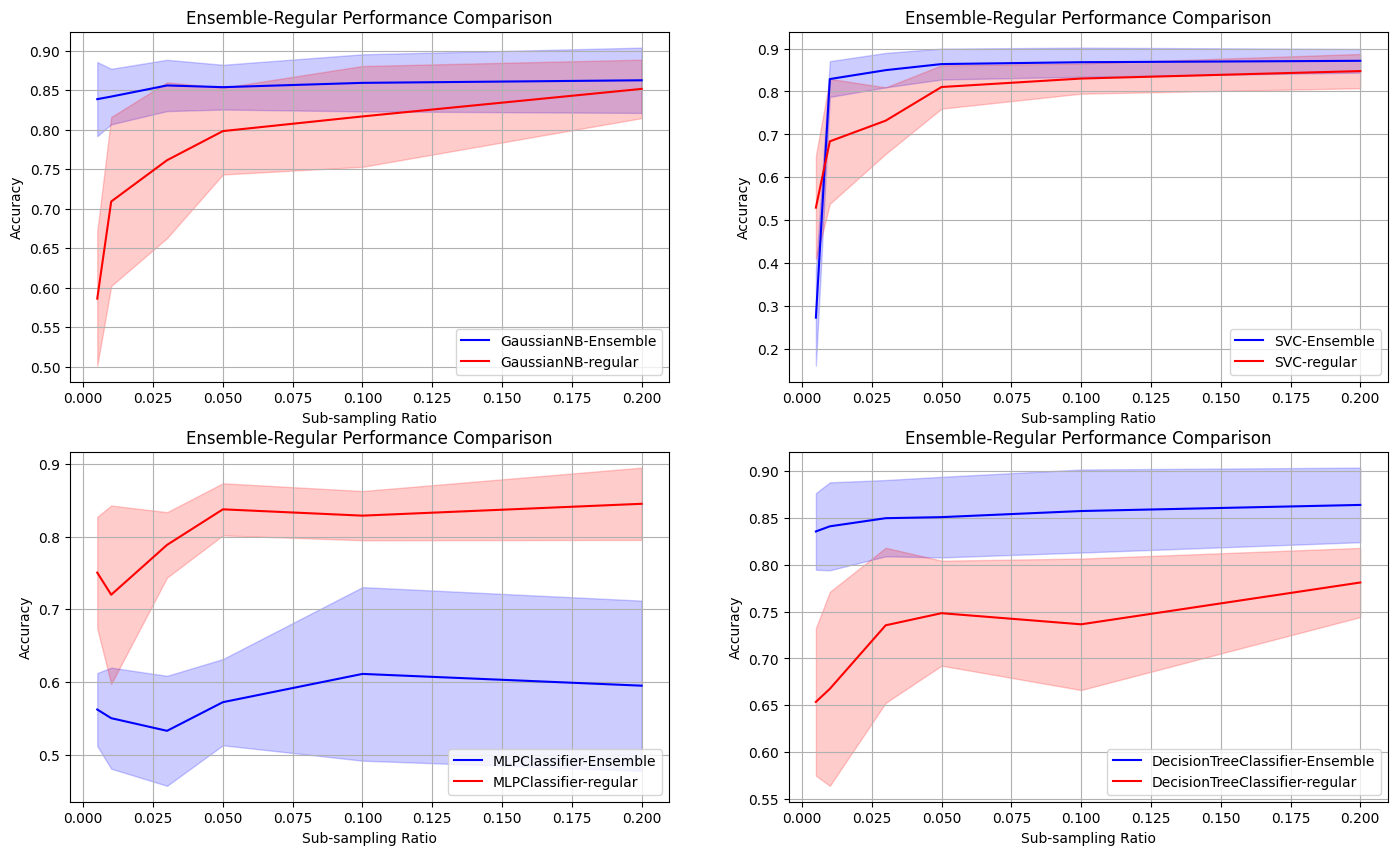

In [158]:
#gather the results
Ensemble_data = {ec:(np.array([Result_enclf2[ec][r][0] for r in sample_ratio_list2]),np.array([Result_enclf2[ec][r][1] for r in sample_ratio_list2])) for ec in ensemble_collections}
regular_data = {ec:(np.array([Result_regular_single[ec][r][0] for r in sample_ratio_list2]),np.array([Result_regular_single[ec][r][1] for r in sample_ratio_list2])) for ec in regular_single_collections}

#get number of classifier types
num_clf = len(ensemble_collections)
nrow = num_clf+1
#2 plot in a row
ncol = 2
#calculate number of cols needed
rows = (num_clf+1)//ncol
_, ax = plt.subplots(nrows=rows, ncols=ncol, figsize=(17, 10))
#iterate through each type of classifier
for i,c in enumerate(Ensemble_data):
    x = i%ncol
    y = i//ncol
    ax[y,x].plot(sample_ratio_list2, Ensemble_data[c][0], label=f'{c}-Ensemble',color='blue')
    ax[y,x].plot(sample_ratio_list2, regular_data[c][0], label=f'{c}-regular',color='red')
    ax[y,x].fill_between(sample_ratio_list2, Ensemble_data[c][0]-Ensemble_data[c][1], Ensemble_data[c][0]+Ensemble_data[c][1], color='blue', alpha=0.2)
    ax[y,x].fill_between(sample_ratio_list2, regular_data[c][0]-regular_data[c][1], regular_data[c][0]+regular_data[c][1], color='red', alpha=0.2)
    ax[y,x].set(xlabel='Sub-sampling Ratio', ylabel='Accuracy', title='Ensemble-Regular Performance Comparison')
    ax[y,x].legend(loc='lower right')
    ax[y,x].grid(True)
plt.show()

### Question6:

As we can see from the above plot, in general, ensemble classifiers are better than single regular classifier.<br>
For Naives Bayes, SVC and Decision Tree, we can see that the ensemble has better generalization performance, as represented by the cross-validated accuracies, and with smaller standard deviation. It proves that even if an individual classifier may not be powerful and only have access to the same ratio of data as a single regular classifier, but the pooling of predictions with majority/probability voting strategy helps reduce error and boost performance.

However, the only exception is this evaluation is the neural network. From the plot of MLPclassifier, we can see that regardless of sub-sampling ratio, the ensemble underperforms a regular classifier in both the accuracies and the variance.
<br>
And more importantly, the ensemble suffers from underfitting, with only about 60% of accuracy in general, which should be caused by the very restrictive hyperparameters of each weak learner of neural network. Because in contrast, the regular neural network, although exposed to only the same ratio of data, generalizes much better.

To conclude, the evaluation tells us that the ensemble with bagging can help with reducing variance, but not with bias, like the case of neural network.